# Exploration & QA/QC Notebook

This notebook is a hands-on companion to the automated pipeline (`run_pipeline.py`). It walks through the same **spatial QA/QC checks** a GIS analyst would do before trusting a dataset: previewing the data, checking for missing values and duplicates, verifying the coordinate reference system (CRS), validating geometries, and checking spatial extents.

Run `python run_pipeline.py` (or at least `scripts/fetch_data.py` + `scripts/clean_data.py`) before running this notebook, so the processed files it reads already exist.

In [1]:
import sys
sys.path.insert(0, "..")
import config

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

boundary = gpd.read_file(config.PHOENIX_BOUNDARY_CLEAN)
facilities = gpd.read_file(config.EPA_FACILITIES_CLEAN)
flood_zones = gpd.read_file(config.FEMA_FLOOD_ZONES_CLEAN)

print("Loaded layers:")
print(f"  boundary   : {len(boundary)} feature(s)")
print(f"  facilities : {len(facilities)} feature(s)")
print(f"  flood zones: {len(flood_zones)} feature(s)")

Loaded layers:
  boundary   : 1 feature(s)
  facilities : 10265 feature(s)
  flood zones: 704 feature(s)


## 1. Preview each dataset

Plain-English: before doing anything else, just *look* at a few rows of each table. This catches obviously wrong column names, encoding issues, or unexpected value formats early.

In [2]:
boundary.head()

,city_name,GEOID,geometry
0,Phoenix,0455000,"MULTIPOLYGON (((-112.12626 33.36182, -112.1255..."


In [3]:
facilities.head()

,registry_id,facility_name,facility_category,epa_programs_raw,site_type,address,city_name_raw,county_name_raw,geometry
0,110000470160,Woodstuff Manufacturing Inc,Hazardous Waste (RCRA),"AIRS/AFS:0401300072, AZURITE:108026, EIS:54851...",STATIONARY,1635 SOUTH 43RD AVENUE,Phoenix,Maricopa,POINT (-112.15188 33.43239)
1,110000470188,Phoenix Brick Yard,Hazardous Waste (RCRA),"AIRS/AFS:0401301014, AZURITE:17453, EIS:881411...",STATIONARY,1814 SOUTH 7TH AVE,Phoenix,Maricopa,POINT (-112.08247 33.43064)
2,110000470197,Western States Petroleum,Hazardous Waste (RCRA),"EIS:7951211, RCRAINFO:AZD982523698, TRIS:85007...",STATIONARY,450 S 15TH AVE,Phoenix,Maricopa,POINT (-112.09131 33.44289)
3,110000470204,On Semiconductor Sci Llc,Hazardous Waste (RCRA),"AIRS/AFS:0401300212, AZURITE:132561, AZURITE:1...",STATIONARY,5005 E MCDOWELL RD,Phoenix,Maricopa,POINT (-111.97080 33.46167)
4,110000470213,Baysystems North America,Hazardous Waste (RCRA),"AZURITE:138666, EIS:927011, RCRAINFO:AZR000511...",STATIONARY,3010 W LINCOLN ST,Phoenix,Maricopa,POINT (-112.12428 33.44222)


In [4]:
flood_zones.head()

,flood_zone,zone_subtype,is_sfha,geometry
0,A,None,T,"POLYGON ((-112.21695 33.50659, -112.21690 33.5..."
1,A,None,T,"POLYGON ((-112.19501 33.49356, -112.19504 33.4..."
2,AH,None,T,"POLYGON ((-112.20784 33.44236, -112.20781 33.4..."
3,A,None,T,"POLYGON ((-112.25001 33.46506, -112.25001 33.4..."
4,A,None,T,"POLYGON ((-112.21525 33.45076, -112.21524 33.4..."


## 2. Check missing values

Plain-English: a GIS layer is only as trustworthy as its attribute table. Nulls in a key field (like a facility's category or a flood zone's code) mean that record can't be classified correctly downstream.

In [5]:
print("Missing values per column -- facilities:")
print(facilities.isna().sum())
print("\nMissing values per column -- flood zones:")
print(flood_zones.isna().sum())

Missing values per column -- facilities:
registry_id            0
facility_name          0
facility_category      0
epa_programs_raw       3
site_type            324
address                9
city_name_raw          0
county_name_raw        0
geometry               0
dtype: int64

Missing values per column -- flood zones:
flood_zone        0
zone_subtype    403
is_sfha           0
geometry          0
dtype: int64


## 3. Check duplicate facility records

Plain-English: EPA's Facility Registry Service occasionally has more than one registry entry pointing at the exact same site (e.g. an old and a new registration). Duplicate coordinates and duplicate registry IDs are both worth knowing about.

In [6]:
dupe_ids = facilities["registry_id"].duplicated().sum()
dupe_coords = facilities.geometry.apply(lambda g: (round(g.x, 5), round(g.y, 5))).duplicated().sum()
print(f"Duplicate registry_id values : {dupe_ids}")
print(f"Facilities sharing an identical (lon, lat) with another facility: {dupe_coords}")

Duplicate registry_id values : 0
Facilities sharing an identical (lon, lat) with another facility: 1461


## 4. Check CRS

Plain-English: the coordinate reference system tells GIS software how to translate the numbers in the geometry column into real-world positions. Every layer here should report `EPSG:4326` (WGS84 lat/lon), since that's what `clean_data.py` standardized them to for storage.

In [7]:
for name, gdf in [("boundary", boundary), ("facilities", facilities), ("flood_zones", flood_zones)]:
    print(f"{name:12s} CRS: {gdf.crs}")

boundary     CRS: EPSG:4326
facilities   CRS: EPSG:4326
flood_zones  CRS: EPSG:4326


## 5. Check geometry validity

Plain-English: an "invalid" geometry usually means a polygon's edges cross themselves. Invalid geometries can silently produce wrong areas, buffers, or spatial joins, so it's important to confirm none remain after cleaning.

In [8]:
for name, gdf in [("boundary", boundary), ("facilities", facilities), ("flood_zones", flood_zones)]:
    n_invalid = (~gdf.geometry.is_valid).sum()
    n_empty = gdf.geometry.is_empty.sum()
    print(f"{name:12s} invalid geometries: {n_invalid:4d}   empty geometries: {n_empty:4d}")

boundary     invalid geometries:    0   empty geometries:    0
facilities   invalid geometries:    0   empty geometries:    0
flood_zones  invalid geometries:    0   empty geometries:    0


## 6. Check bounds / extents

Plain-English: printing each layer's bounding box is a quick sanity check that everything actually lines up in the same part of the world (e.g. facilities shouldn't have a bounding box wildly bigger than the Phoenix boundary).

In [9]:
for name, gdf in [("boundary", boundary), ("facilities", facilities), ("flood_zones", flood_zones)]:
    minx, miny, maxx, maxy = gdf.total_bounds
    print(f"{name:12s} bounds: lon [{minx:.3f}, {maxx:.3f}]  lat [{miny:.3f}, {maxy:.3f}]")

boundary     bounds: lon [-112.324, -111.926]  lat [33.290, 33.918]
facilities   bounds: lon [-112.324, -111.926]  lat [33.291, 33.906]
flood_zones  bounds: lon [-112.375, -111.787]  lat [33.188, 34.016]


## 7. Preview simple maps

A quick static plot per layer -- not the polished final map (that's `scripts/make_maps.py`), just a fast visual gut-check that geometries look like what we expect (a city outline, scattered points, and irregular flood polygons).

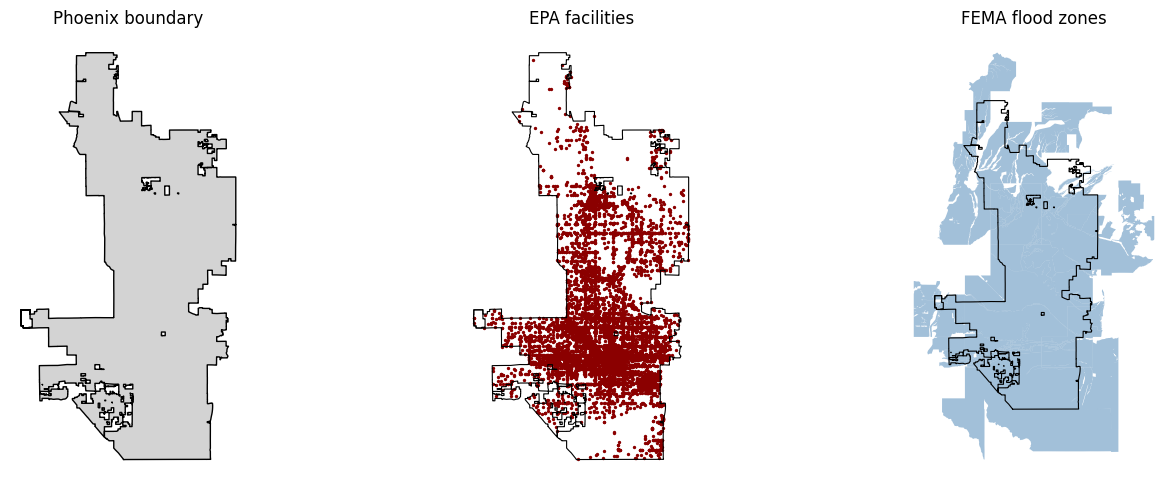

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
boundary.plot(ax=axes[0], color="lightgrey", edgecolor="black")
axes[0].set_title("Phoenix boundary")

boundary.boundary.plot(ax=axes[1], color="black", linewidth=0.8)
facilities.plot(ax=axes[1], markersize=2, color="darkred")
axes[1].set_title("EPA facilities")

boundary.boundary.plot(ax=axes[2], color="black", linewidth=0.8)
flood_zones.plot(ax=axes[2], color="steelblue", alpha=0.5)
axes[2].set_title("FEMA flood zones")

for ax in axes:
    ax.set_axis_off()
fig.tight_layout()
plt.show()

## 8. Quick look at the analysis summary (if available)

If `scripts/analysis.py` has already been run, its summary CSV is loaded here purely for a quick look -- the authoritative numbers live in `data/processed/summary_statistics.csv` and `reports/gis_summary.pdf`.

In [11]:
if config.SUMMARY_CSV.exists():
    summary = pd.read_csv(config.SUMMARY_CSV)
    display(summary)
else:
    print("Run scripts/analysis.py first to generate the summary statistics CSV.")

,metric,value
0,total_facilities_analyzed,10265.00
1,facilities_within_0.5mi_of_flood_zone,4205.00
2,pct_facilities_within_0.5mi_of_flood_zone,40.96
3,category_count::Other / State-Registered Facility,5406.00
4,category_count::Hazardous Waste (RCRA),3537.00
5,category_count::Water Discharge (NPDES),844.00
6,category_count::Water/Air Compliance (ICIS),264.00
7,category_count::Air Emissions (EIS),76.00
8,category_count::Toxics Release Inventory (TRI),75.00
9,category_count::Air Emissions (AIRS/AFS),37.00
